# Session 2B — Pretrained predictions

Load, validate, and visualize the verified pretrained DGAT prediction artifact.

Work through the parts in order. Each part ends by writing its existing JSON checkpoint,
so the consolidation changes file organization without removing pause/resume milestones.


In [1]:
from pathlib import Path
import sys

# Locates the cloned tutorial in Google Colab after Session 0 setup.
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
colab_root = Path("/content/ECCB-2026-Tutorial/hands-on_tutorial")
if colab_root.is_dir():
    candidates.insert(0, colab_root.resolve())

for candidate in candidates:
    if (candidate / "src" / "dgat_tutorial").is_dir():
        tutorial_root = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find hands-on_tutorial/. In Colab, run notebooks/session_00/00_colab_setup.ipynb first."
    )

sys.path.insert(0, str(tutorial_root / "src"))

from dgat_tutorial.checkpoints import tutorial_paths, write_checkpoint

paths = tutorial_paths(tutorial_root)
print(f"Tutorial root: {paths.root}")


Tutorial root: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial


## Session 2 · Part 4 — Load and validate pretrained predictions

**Goal:** use a verified DGAT artifact after learning how it was built and trained. Conference laptops
load committed official predictions for speed and reproducibility; the organizer command below can
regenerate them from the RNA graph and saved RNA-encoder/protein-decoder weights.


### 1. Inspect prediction provenance before trusting values


In [2]:
from dgat_tutorial.dgat import load_prediction_metadata, load_prediction_table, write_prediction_artifact

source_path = paths.raw_data / "dgat_predictions.csv"
if not source_path.is_file():
    raise FileNotFoundError(f"Missing verified prediction table: {source_path}")
predicted_proteins = load_prediction_table(str(source_path))
metadata = load_prediction_metadata(source_path)
if metadata is None:
    raise FileNotFoundError(f"Missing provenance sidecar for {source_path}")
display(metadata, predicted_proteins.head())


{'method': 'official_dgat',
 'source': 'external/DGAT_assets/data/Tonsil_RNA.h5ad',
 'evaluation_note': 'Official pretrained DGAT inference via fill_genes + preprocess_ST + protein_predict. Before treating Tonsil scores as held-out accuracy, confirm exclusion from training/checkpoint selection with the DGAT authors.',
 'rows': 4191,
 'proteins': 31,
 'protein_names': ['ACTA2',
  'BCL2',
  'CCR7',
  'CD14',
  'CD163',
  'CD19',
  'CD27',
  'CD274',
  'CD3E',
  'CD4',
  'CD40',
  'CD68',
  'CD8A',
  'CEACAM8',
  'CR2',
  'CXCR5',
  'EPCAM',
  'FCGR3A',
  'HLA_DRA',
  'ITGAM',
  'ITGAX',
  'KRT5',
  'MS4A1',
  'PAX5',
  'PCNA',
  'PDCD1',
  'PECAM1',
  'PTPRC_1',
  'PTPRC_2',
  'SDC1',
  'VIM'],
 'hidden_dim': 1024,
 'dropout_rate': 0.3,
 'spatial_knn_k': 6,
 'molecular_knn_k': 10,
 'rna_pca_variance': 0.85,
 'train_loss_weights': [5.0, 1.0, 1.0, 3.0, 1.0],
 'preprocessing': {'training_path': 'qc_control_cytassist + normalize (MT/prevalence/CLR)',
  'inference_path': 'fill_genes + preproc

,ACTA2,BCL2,CCR7,CD14,CD163,CD19,CD27,CD274,CD3E,CD4,...,KRT5,MS4A1,PAX5,PCNA,PDCD1,PECAM1,PTPRC_1,PTPRC_2,SDC1,VIM
AACACGTGCATCGCAC-1,0.844668,0.919761,0.696354,0.623823,0.684123,0.782110,0.741168,0.631120,0.716439,0.692335,...,0.761715,0.885237,1.291600,1.043870,0.804489,0.583377,0.782208,0.726001,0.740317,0.841340
AACACTTGGCAAGGAA-1,0.721599,0.345691,0.652400,0.695595,0.718327,0.938137,0.676115,0.863304,0.578019,0.674952,...,0.499353,1.270285,1.314461,1.493167,0.928994,0.496727,0.745387,0.647744,0.825236,0.616368
AACAGGAAGAGCATAG-1,1.107814,0.606627,0.701825,0.637102,0.686137,0.832594,0.795600,0.997879,0.883906,0.733328,...,0.300940,1.100775,0.864704,1.422271,0.910957,0.600969,0.828412,0.886849,0.787895,0.944309
AACAGGATTCATAGTT-1,0.469383,0.462001,0.722230,0.688025,0.756281,0.734914,0.675407,1.682116,0.426733,0.615458,...,2.954318,0.892347,0.868905,0.944449,0.545179,0.852347,0.837411,0.429503,0.815262,0.664564
AACAGGCCAACGATTA-1,0.434048,0.266021,0.695013,0.561265,0.671412,0.546829,0.488821,1.120771,0.298064,0.543978,...,2.974102,0.550547,0.481009,0.784073,0.516746,0.504971,0.564429,0.269495,0.927674,0.429913


### 2. The inference operation represented by this artifact

```python
z_rna = encoder_rna(x_rna, rna_edge_index)
predicted_protein = decoder_protein(z_rna)
```

To regenerate with official assets, run `scripts/run_official_dgat_prediction.py` in the separate official
environment. That script discovers the matching common-feature lists and checkpoint layout, then calls
upstream `Model.Train_and_Predict.protein_predict`.


In [3]:
output_path = paths.processed_data / "predicted_proteins.csv"
metadata_path = write_prediction_artifact(
    predicted_proteins, output_path,
    method=str(metadata["method"]), source=str(metadata["source"]),
    evaluation_note=str(metadata["evaluation_note"]),
)
manifest = write_checkpoint(
    "2.4", [output_path, metadata_path],
    summary={"spots": len(predicted_proteins), "proteins": predicted_proteins.shape[1]}, start=paths.root,
)
print(f"Checkpoint written: {manifest}")


Checkpoint written: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/checkpoints/session_02/part_2_4.json


### Check

Do not evaluate a model on protein values that were used to train or select it. Read the sidecar's
evaluation note and confirm that spot IDs and protein names match the target dataset.


## Session 2 · Part 5 — Visualize inferred protein landscapes

**Goal:** inspect prediction distributions and spatial patterns before calculating accuracy metrics.
A plausible-looking map is not proof of correctness; it is a diagnostic for range compression, isolated
artifacts, tissue-edge effects, and expected regional structure.


### 1. Align predictions to spatial coordinates


In [5]:
import matplotlib.pyplot as plt

from dgat_tutorial.checkpoints import preferred_prediction_path
from dgat_tutorial.data import load_tutorial_data
from dgat_tutorial.dgat import load_prediction_table
from dgat_tutorial.plotting import plot_spatial_feature

dataset = load_tutorial_data(paths.raw_data)
prediction_path = preferred_prediction_path(paths)
predicted = load_prediction_table(str(prediction_path))
common_spots = dataset.spots.index.intersection(predicted.index)
if common_spots.empty:
    raise ValueError("Spatial data and predictions have no shared spot IDs; check that the assets match.")
spots = dataset.spots.loc[common_spots]
predicted = predicted.loc[common_spots]
print(f"Aligned {len(common_spots)} spots and {predicted.shape[1]} predicted proteins")


Aligned 4191 spots and 31 predicted proteins


#### Figure 8 — Prediction distributions


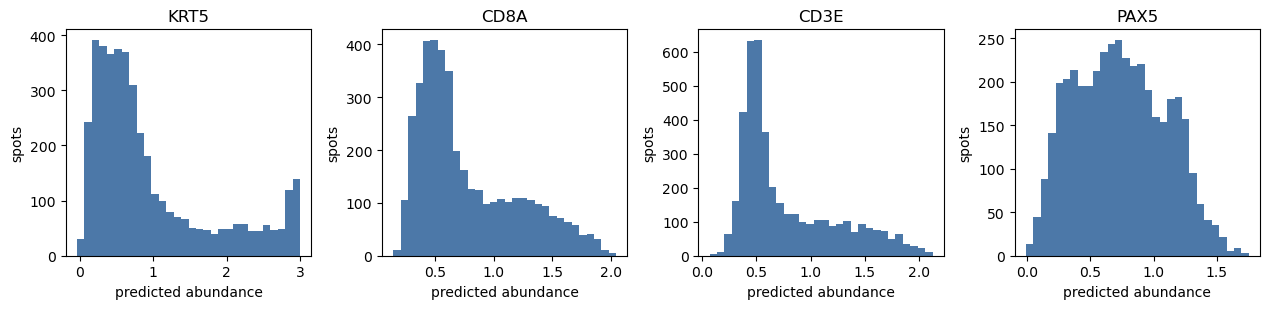

In [6]:
# Prefer robust IQR over variance so a few outlier spots do not dominate feature selection.
iqr = predicted.quantile(0.75) - predicted.quantile(0.25)
proteins_to_plot = list(iqr.nlargest(min(4, predicted.shape[1])).index)
fig, axes = plt.subplots(1, len(proteins_to_plot), figsize=(3.2 * len(proteins_to_plot), 3.2))
axes = [axes] if len(proteins_to_plot) == 1 else axes
for ax, protein in zip(axes, proteins_to_plot):
    ax.hist(predicted[protein], bins=30, color="#4c78a8")
    ax.set_title(protein); ax.set_xlabel("predicted abundance"); ax.set_ylabel("spots")
distribution_path = paths.figures / "session02_prediction_distributions.png"
fig.tight_layout(); fig.savefig(distribution_path, dpi=160, bbox_inches="tight"); plt.show()


#### Figure 9 — Predicted spatial protein maps


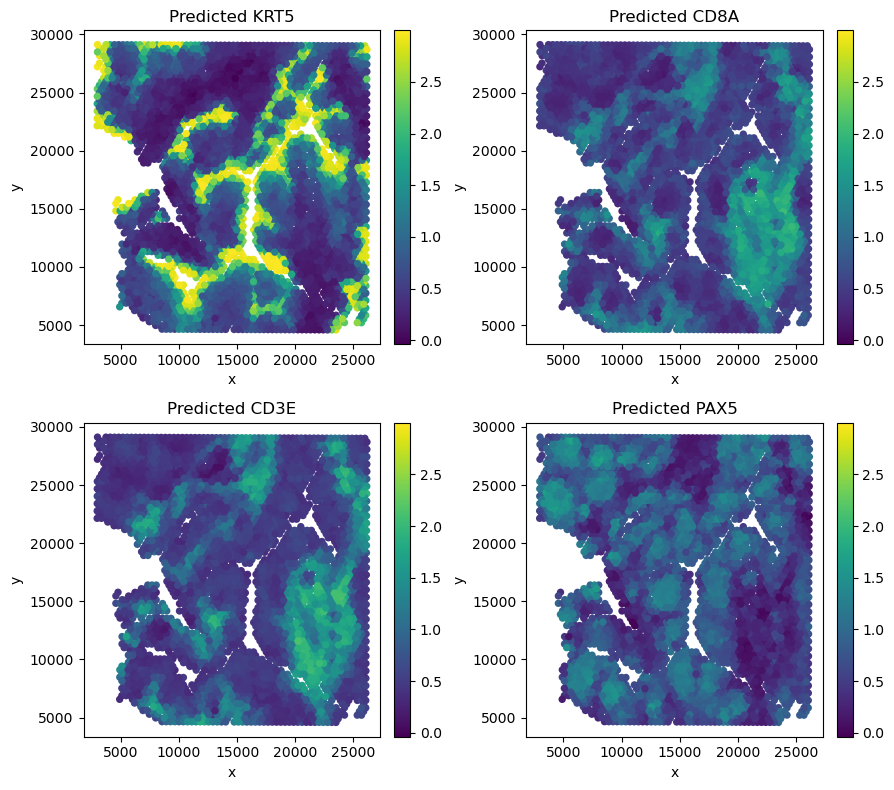

In [7]:
n_cols = 2
n_rows = (len(proteins_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 4 * n_rows), squeeze=False)
# Shared color scale across the selected panel for fair visual comparison.
shared_vmin = float(predicted[proteins_to_plot].min().min())
shared_vmax = float(predicted[proteins_to_plot].max().max())
for ax, protein in zip(axes.ravel(), proteins_to_plot):
    plot_spatial_feature(
        spots, predicted[protein], f"Predicted {protein}", ax=ax, vmin=shared_vmin, vmax=shared_vmax
    )
for ax in axes.ravel()[len(proteins_to_plot):]: ax.axis("off")
spatial_path = paths.figures / "session02_predicted_protein_maps.png"
fig.tight_layout(); fig.savefig(spatial_path, dpi=160, bbox_inches="tight"); plt.show()


In [8]:
manifest = write_checkpoint(
    "2.5", [prediction_path, distribution_path, spatial_path],
    summary={"spots": len(common_spots), "proteins_plotted": proteins_to_plot}, start=paths.root,
)
print(f"Checkpoint written: {manifest}")


Checkpoint written: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/checkpoints/session_02/part_2_5.json


### Check

Identify one map worth evaluating and one possible artifact. Then continue to Session 3, where observed
proteins are used for pointwise correlation, spatial coherence, and side-by-side landscape comparison.
